In [4]:
# + Import lại toàn bộ hàm cần dùng cho notebook 2
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

from data_processing import load_all_source_tables
from data_processing import clean_source_tables
from data_processing import build_daily_model_base
from data_processing import build_monthly_panel

from train import train_best_models
from predict import predict_latest

print("Import thành công")

Import thành công


In [5]:
# + Đọc dữ liệu nguồn, chỉ giữ đúng 3 loại gạo R01 R02 R03
source = load_all_source_tables(
    project_id="dwm-final-487216",
    dataset_id="nong_san_dbscl",
)
source = clean_source_tables(source)

daily_base = build_daily_model_base(source)

print("Rice ID trong daily_base:")
display(daily_base["rice_id"].value_counts().sort_index())

panel = build_monthly_panel(
    daily_base,
    horizons=(1, 2, 3),
    max_target_lag=6,
    max_feature_lag=3,
    rolling_windows=(2, 3, 6),
)

print("Rice ID trong panel:")
display(panel["rice_id"].value_counts().sort_index())

print("Panel shape:", panel.shape)
display(panel.head())

Rice ID trong daily_base:


rice_id
R01    618
R02    618
R03    618
Name: count, dtype: int64

Rice ID trong panel:


rice_id
R01    27
R02    27
R03    27
Name: count, dtype: int64

Panel shape: (81, 163)


,date_id,region_id,rice_id,price_rice,avg_temperature,max_temp,min_temp,rainfall_mm,avg_wind_speed,production_ton,...,price_fert_F03_roll_std_6,price_rice_diff_1,price_rice_pct_change_1,target_t_plus_1,direction_t_plus_1,target_t_plus_2,direction_t_plus_2,target_t_plus_3,direction_t_plus_3,row_is_latest
0,2024-01-01,1,R01,7781.818182,27.081818,28.581818,25.581818,0.390909,10.681818,20330000.0,...,NaN,NaN,NaN,7371.428571,0.0,7879.629630,1.0,7533.333333,0.0,False
1,2024-02-01,1,R01,7371.428571,27.964286,29.464286,26.464286,0.078571,13.407143,20330000.0,...,435.067089,-410.389610,-0.052737,7879.629630,1.0,7533.333333,1.0,7920.833333,1.0,False
2,2024-03-01,1,R01,7879.629630,29.518519,31.018519,28.018519,0.274074,14.781481,8200000.0,...,403.237892,508.201058,0.068942,7533.333333,0.0,7920.833333,1.0,7122.550000,0.0,False
3,2024-04-01,1,R01,7533.333333,31.312500,32.812500,29.812500,0.150000,15.241667,11160000.0,...,568.135640,-346.296296,-0.043948,7920.833333,1.0,7122.550000,0.0,7170.833333,0.0,False
4,2024-05-01,1,R01,7920.833333,28.816667,30.316667,27.316667,9.825000,14.041667,11160000.0,...,540.769271,387.500000,0.051438,7122.550000,0.0,7170.833333,0.0,7596.153846,0.0,False


In [6]:
# + Train và benchmark model trên panel mới
scores, selected = train_best_models(
    panel_df=panel,
    model_dir="../models",
    horizons=(1, 2, 3),
    min_train_months=12,
    valid_months=1,
)

display(selected)
display(scores.head())

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.083e+05, tolerance: 4.916e+03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.248e+05, tolerance: 5.255e+03
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.411e+05, tolerance: 5.478e

,horizon,best_regression_model,best_classification_model,regression_model_path,classification_model_path
0,1,random_forest,logistic_regression,../models/rice_price_reg_h1.joblib,../models/rice_price_dir_h1.joblib
1,2,random_forest,random_forest_cls,../models/rice_price_reg_h2.joblib,../models/rice_price_dir_h2.joblib
2,3,gradient_boosting,catboost_cls,../models/rice_price_reg_h3.joblib,../models/rice_price_dir_h3.joblib


,rmse,mae,mape,r2,task,horizon,model_name,fold,accuracy
0,315.861155,275.302616,4.519569,0.450792,regression,1,elastic_net,1,NaN
1,475.343829,446.176339,7.481432,-1.233661,regression,1,elastic_net,2,NaN
2,2097.489937,1733.529365,20.907494,-0.871033,regression,1,elastic_net,3,NaN
3,3359.130671,3026.835414,50.470944,-63.150042,regression,1,elastic_net,4,NaN
4,1225.187063,916.588056,16.671734,-0.319901,regression,1,elastic_net,5,NaN


In [7]:
# + Tổng hợp kết quả benchmark
reg_summary = (
    scores[scores["task"] == "regression"]
    .groupby(["horizon", "model_name"], as_index=False)[["rmse", "mae", "mape", "r2"]]
    .mean()
    .sort_values(["horizon", "rmse", "mae"])
)

cls_summary = (
    scores[scores["task"] == "classification"]
    .groupby(["horizon", "model_name"], as_index=False)[["accuracy"]]
    .mean()
    .sort_values(["horizon", "accuracy"], ascending=[True, False])
)

display(reg_summary)
display(cls_summary)

,horizon,model_name,rmse,mae,mape,r2
4,1,random_forest,780.851006,654.560690,9.779381,-0.899902
0,1,catboost,792.342877,687.008572,10.408277,-0.906570
3,1,gradient_boosting,832.693675,707.827456,10.504512,-1.324866
2,1,extra_trees,903.090766,787.517249,12.206214,-2.869887
1,1,elastic_net,1283.116485,1103.418258,17.157794,-11.168629
9,2,random_forest,819.935633,624.019057,9.181238,-0.576705
5,2,catboost,889.389312,693.147545,10.217832,-1.430016
8,2,gradient_boosting,913.022741,721.249846,10.505696,-1.721156
7,2,extra_trees,922.084607,715.033121,10.809378,-1.052671
6,2,elastic_net,1045.036695,842.403606,12.556240,-3.418447


,horizon,model_name,accuracy
3,1,logistic_regression,0.800000
0,1,catboost_cls,0.733333
4,1,random_forest_cls,0.733333
2,1,gradient_boosting_cls,0.633333
1,1,extra_trees_cls,0.566667
9,2,random_forest_cls,0.833333
5,2,catboost_cls,0.666667
6,2,extra_trees_cls,0.666667
7,2,gradient_boosting_cls,0.666667
8,2,logistic_regression,0.500000


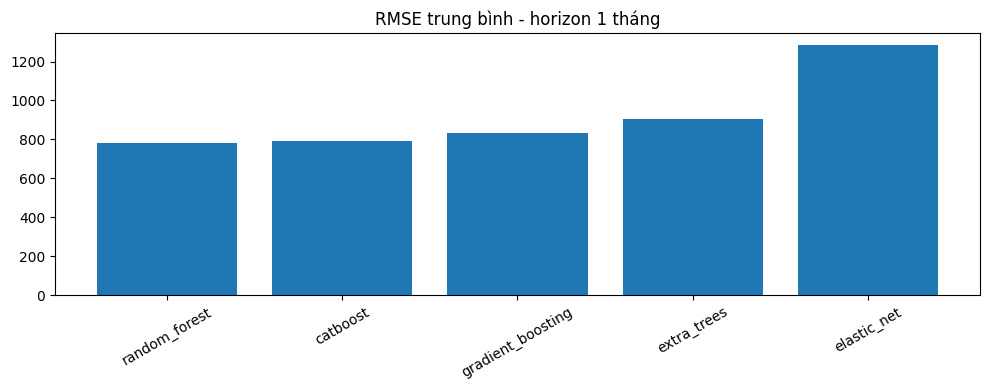

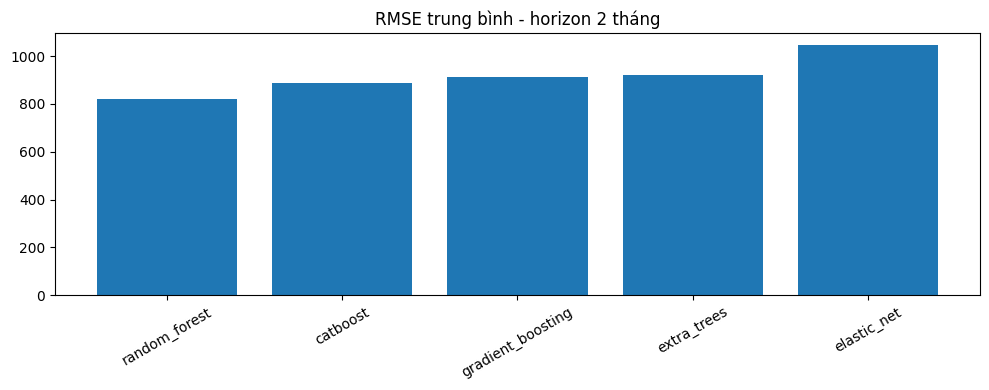

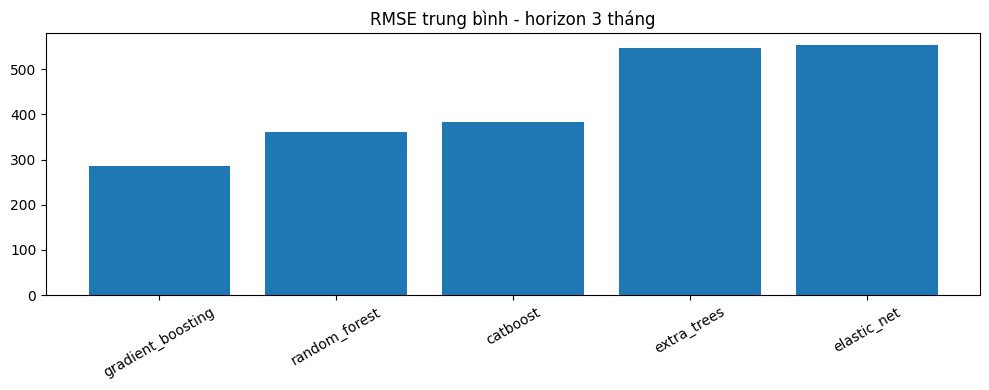

In [8]:
# + Vẽ nhanh RMSE theo horizon
for horizon in sorted(reg_summary["horizon"].unique()):
    tmp = reg_summary.loc[reg_summary["horizon"] == horizon].sort_values("rmse")

    plt.figure(figsize=(10, 4))
    plt.bar(tmp["model_name"], tmp["rmse"])
    plt.title(f"RMSE trung bình - horizon {horizon} tháng")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [11]:
# + Xuất file forecast theo dạng tháng dễ đọc hơn
forecast_export = forecast_df.copy()

forecast_export["thang_goc_du_bao"] = pd.to_datetime(forecast_export["date_id"]).dt.strftime("%m/%Y")
forecast_export["thang_du_bao"] = pd.to_datetime(forecast_export["forecast_month"]).dt.strftime("%m/%Y")
forecast_export["nam_du_bao"] = pd.to_datetime(forecast_export["forecast_month"]).dt.year
forecast_export["thang_so_du_bao"] = pd.to_datetime(forecast_export["forecast_month"]).dt.month

forecast_export = forecast_export.rename(columns={
    "forecast_horizon_month": "so_thang_du_bao",
    "price_rice": "gia_hien_tai",
    "predicted_price": "gia_du_bao",
    "predicted_direction_label": "xu_huong_du_bao",
})

forecast_export = forecast_export[
    [
        "thang_goc_du_bao",
        "thang_du_bao",
        "nam_du_bao",
        "thang_so_du_bao",
        "so_thang_du_bao",
        "region_id",
        "region_name",
        "rice_id",
        "rice_name",
        "rice_group",
        "gia_hien_tai",
        "gia_du_bao",
        "xu_huong_du_bao",
    ]
].sort_values(
    ["nam_du_bao", "thang_so_du_bao", "rice_id"]
).reset_index(drop=True)

forecast_export.to_csv(
    "../outputs/forecast_theo_thang_sach.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu: ../outputs/forecast_theo_thang_sach.csv")
display(forecast_export)

Đã lưu: ../outputs/forecast_theo_thang_sach.csv


,thang_goc_du_bao,thang_du_bao,nam_du_bao,thang_so_du_bao,so_thang_du_bao,region_id,region_name,rice_id,rice_name,rice_group,gia_hien_tai,gia_du_bao,xu_huong_du_bao
0,03/2026,04/2026,2026,4,1,1,Đồng bằng sông Cửu Long,R01,Gạo nguyên liệu IR 504,Lúa tươi,5410.0,5789.18,Tăng
1,03/2026,04/2026,2026,4,1,1,Đồng bằng sông Cửu Long,R02,Gạo nguyên liệu Đài Thơm 8,Lúa tươi,6238.8,6472.01,Tăng
2,03/2026,04/2026,2026,4,1,1,Đồng bằng sông Cửu Long,R03,Gạo nguyên liệu OM5451,Lúa tươi,7560.0,6303.54,Giảm/Đi ngang
3,03/2026,05/2026,2026,5,2,1,Đồng bằng sông Cửu Long,R01,Gạo nguyên liệu IR 504,Lúa tươi,5410.0,5847.54,Giảm/Đi ngang
4,03/2026,05/2026,2026,5,2,1,Đồng bằng sông Cửu Long,R02,Gạo nguyên liệu Đài Thơm 8,Lúa tươi,6238.8,6188.47,Giảm/Đi ngang
5,03/2026,05/2026,2026,5,2,1,Đồng bằng sông Cửu Long,R03,Gạo nguyên liệu OM5451,Lúa tươi,7560.0,6139.34,Giảm/Đi ngang
6,03/2026,06/2026,2026,6,3,1,Đồng bằng sông Cửu Long,R01,Gạo nguyên liệu IR 504,Lúa tươi,5410.0,7798.41,Tăng
7,03/2026,06/2026,2026,6,3,1,Đồng bằng sông Cửu Long,R02,Gạo nguyên liệu Đài Thơm 8,Lúa tươi,6238.8,6169.76,Giảm/Đi ngang
8,03/2026,06/2026,2026,6,3,1,Đồng bằng sông Cửu Long,R03,Gạo nguyên liệu OM5451,Lúa tươi,7560.0,5871.91,Giảm/Đi ngang
